# SQL Analysis with DuckDB

The rest of this project uses pandas for data processing (see `notebooks/01_solar_forecasting_plant1.ipynb`, `notebooks/02_solar_forecasting_plant2.ipynb`, and `src/dataset.py`). This notebook is a supplementary demonstration of SQL skills on the same dataset, using [DuckDB](https://duckdb.org/) — it is not part of the main pipeline.

DuckDB can query CSV files directly with SQL, so no separate database or ETL step is needed. To keep this self-contained (in case it's read on its own), Parts 1-2 follow the same CRISP-DM shape as the main notebooks for Plant 1 — data understanding, then data preparation — re-derived in SQL. Part 3 repeats data understanding and preparation for Plant 2, which needs different handling (see below). Part 4 covers a few additional query patterns that come up often in analytics work (funnel/cohort analysis, daily KPI tracking, etc.).

The feature tables built here match `src/dataset.py`'s `preprocess_plant1_data`/`preprocess_plant2_data` (one row per timestamp, median across inverters) — trained through `src/train.py`, they reproduce its reported metrics almost exactly. Note this is a different row granularity than `notebooks/01_solar_forecasting_plant1.ipynb`, which keeps one row per inverter per timestamp and reports different numbers (388.50 kW RMSE) as a result — both are valid, just not directly comparable.


In [1]:
# Setup
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect()

GEN_PATH = '../data/raw/Plant_1_Generation_Data.csv'
WEATHER_PATH = '../data/raw/Plant_1_Weather_Sensor_Data.csv'


## Part 1: Data Understanding — Plant 1

### 1.1 Schema and row counts

`DESCRIBE` shows column names and types without loading the file; useful as the very first check on an unfamiliar CSV.


In [2]:
schema_df = con.sql(f"DESCRIBE SELECT * FROM read_csv_auto('{GEN_PATH}')").df()
print(schema_df)

row_count = con.sql(f"SELECT COUNT(*) AS n FROM read_csv_auto('{GEN_PATH}')").df()
print(f"\n{row_count['n'][0]:,} rows in the generation file")


   column_name column_type null   key default extra
0    DATE_TIME     VARCHAR  YES  None    None  None
1     PLANT_ID      BIGINT  YES  None    None  None
2   SOURCE_KEY     VARCHAR  YES  None    None  None
3     DC_POWER      DOUBLE  YES  None    None  None
4     AC_POWER      DOUBLE  YES  None    None  None
5  DAILY_YIELD      DOUBLE  YES  None    None  None
6  TOTAL_YIELD      DOUBLE  YES  None    None  None

68,778 rows in the generation file


### 1.2 Summary statistics

`SUMMARIZE` gives min/max/mean/quartiles/null% for every column in one call — a quick sanity check on ranges before writing any real query (e.g. confirming irradiation is never negative).


In [3]:
summary_df = con.sql(f"""
    SUMMARIZE SELECT AMBIENT_TEMPERATURE, MODULE_TEMPERATURE, IRRADIATION
    FROM read_csv_auto('{WEATHER_PATH}')
""").df()
summary_df


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,AMBIENT_TEMPERATURE,DOUBLE,20.398504866666666,35.25248613333334,3109,25.5316057175644,3.354855664435953,22.70766045227794,24.6145920238359,27.921700322136704,3182,0.0
1,MODULE_TEMPERATURE,DOUBLE,18.140415466666663,65.54571366666664,4632,31.091015378426455,12.261221623078292,21.092510408622548,24.623230925286393,41.34796062424382,3182,0.0
2,IRRADIATION,DOUBLE,0.0,1.2216518466666668,1610,0.228312830065651,0.3008363668152484,0.0,0.025051183615657887,0.448547093783654,3182,0.0


### 1.3 Visualization: diurnal power profile

Average `DC_POWER` by time-of-day across all 34 days, to confirm the data follows the expected solar curve (zero overnight, peak around midday) before trusting anything built on top of it.


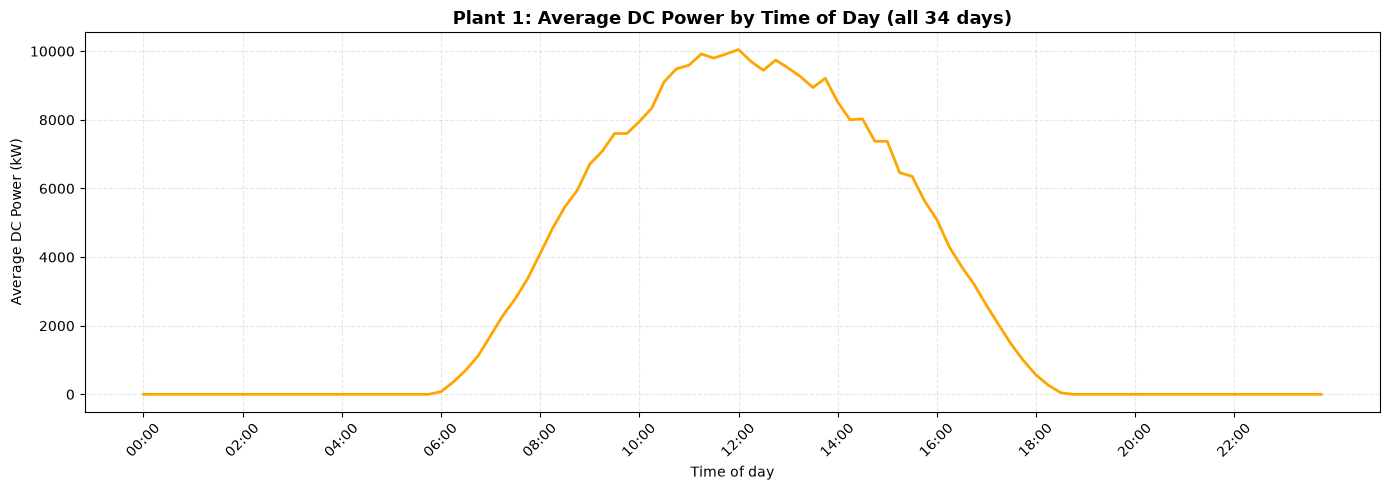

In [4]:
diurnal_df = con.sql(f"""
    SELECT
        strftime(strptime(DATE_TIME, '%d-%m-%Y %H:%M'), '%H:%M') AS time_of_day,
        AVG(DC_POWER) AS avg_dc_power
    FROM read_csv_auto('{GEN_PATH}')
    GROUP BY time_of_day
    ORDER BY time_of_day
""").df()

plt.figure(figsize=(14, 5))
plt.plot(diurnal_df['time_of_day'], diurnal_df['avg_dc_power'], color='orange', lw=2)
plt.title('Plant 1: Average DC Power by Time of Day (all 34 days)', fontsize=13, fontweight='bold')
plt.xlabel('Time of day')
plt.ylabel('Average DC Power (kW)')
plt.xticks(diurnal_df['time_of_day'][::8], rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### 1.4 Anomaly detection: peak-hour zero-power readings

`COUNT(*) FILTER (WHERE ...)` counts zero-power readings during peak sun hours (11:00-15:00) per inverter per day, without a separate subquery. More than 4 such readings (over 1 continuous hour) points to a hardware fault rather than a passing cloud — the same rule used in `notebooks/01_solar_forecasting_plant1.ipynb`.


In [5]:
anomaly_df = con.sql(f"""
    WITH parsed AS (
        SELECT
            strptime(DATE_TIME, '%d-%m-%Y %H:%M') AS ts,
            strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE AS day,
            SOURCE_KEY, DC_POWER
        FROM read_csv_auto('{GEN_PATH}')
    )
    SELECT day, SOURCE_KEY, COUNT(*) FILTER (WHERE DC_POWER = 0.0) AS zero_count
    FROM parsed
    WHERE strftime(ts, '%H:%M') BETWEEN '11:00' AND '15:00'
    GROUP BY day, SOURCE_KEY
    HAVING COUNT(*) FILTER (WHERE DC_POWER = 0.0) > 4
    ORDER BY day, SOURCE_KEY
""").df()
print(f"{len(anomaly_df)} inverter/day combination(s) flagged as likely hardware faults")
anomaly_df


6 inverter/day combination(s) flagged as likely hardware faults


,day,SOURCE_KEY,zero_count
0,2020-06-07,1BY6WEcLGh8j5v7,7
1,2020-06-07,bvBOhCH3iADSZry,8
2,2020-06-07,wCURE6d3bPkepu2,5
3,2020-06-07,z9Y9gH1T5YWrNuG,6
4,2020-06-14,1BY6WEcLGh8j5v7,12
5,2020-06-14,bvBOhCH3iADSZry,12


### 1.5 Missing-data check

A `WITH` clause lets a multi-step check read top to bottom: parse timestamps, aggregate to daily counts, then filter for days with fewer than the expected 2,112 readings (22 inverters x 96 fifteen-minute intervals). Three of the flagged days — May 19-21 — are a full 3-day outage rather than partial dropouts; that's addressed directly in data preparation below.


In [6]:
missing_data_df = con.sql(f"""
    WITH parsed AS (
        SELECT
            strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE AS day,
            DC_POWER
        FROM read_csv_auto('{GEN_PATH}')
    ),
    daily_counts AS (
        SELECT day, COUNT(*) AS row_count, MAX(DC_POWER) AS dc_max
        FROM parsed
        GROUP BY day
    )
    SELECT day, row_count, dc_max
    FROM daily_counts
    WHERE row_count < 2112
    ORDER BY day
""").df()
print(f"{len(missing_data_df)} day(s) with fewer than 2,112 readings")
missing_data_df


19 day(s) with fewer than 2,112 readings


,day,row_count,dc_max
0,2020-05-15,1954,12319.14286
1,2020-05-16,1934,11986.57143
2,2020-05-19,1990,11911.50000
3,2020-05-20,1672,13241.14286
4,2020-05-21,1368,14038.28571
5,2020-05-22,2028,14300.28571
6,2020-05-23,1958,13848.00000
7,2020-05-25,2060,13060.71429
8,2020-05-26,2072,13434.42857
9,2020-05-27,2052,13402.87500


## Part 2: Data Preparation — Plant 1

### 2.1 Preprocessing: drop the blackout window, then median-impute the rest

Two separate fixes, based on what 1.5 found:
1. May 19-21 is a full 3-day outage with no usable signal — dropped entirely (`WHERE ... NOT BETWEEN ...`).
2. The peak-hour zero-power readings found in 1.4 are milder, isolated faults — repaired in place. `MEDIAN(DC_POWER) OVER (PARTITION BY ts)` computes the cross-inverter median at each timestamp as a window function, then `CASE WHEN` replaces only the faulty peak-hour zero readings with it.


In [7]:
cleaned_df = con.sql(f"""
    WITH parsed AS (
        SELECT
            strptime(DATE_TIME, '%d-%m-%Y %H:%M') AS ts,
            SOURCE_KEY, DC_POWER
        FROM read_csv_auto('{GEN_PATH}')
        WHERE strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE NOT BETWEEN DATE '2020-05-19' AND DATE '2020-05-21'
    ),
    with_median AS (
        SELECT *, MEDIAN(DC_POWER) OVER (PARTITION BY ts) AS healthy_median
        FROM parsed
    )
    SELECT
        ts, SOURCE_KEY, DC_POWER,
        CASE
            WHEN strftime(ts, '%H:%M') BETWEEN '11:00' AND '15:00' AND DC_POWER = 0.0
            THEN healthy_median
            ELSE DC_POWER
        END AS dc_power_cleaned
    FROM with_median
""").df()

changed = cleaned_df[cleaned_df['DC_POWER'] != cleaned_df['dc_power_cleaned']]
print(f"{len(cleaned_df):,} rows remaining after dropping the blackout window")
print(f"{len(changed)} reading(s) replaced by median imputation")
changed.head()


63,748 rows remaining after dropping the blackout window
58 reading(s) replaced by median imputation


,ts,SOURCE_KEY,DC_POWER,dc_power_cleaned
1972,2020-06-14 11:30:00,1BY6WEcLGh8j5v7,0.0,9633.571429
1983,2020-06-14 11:30:00,bvBOhCH3iADSZry,0.0,9633.571429
1994,2020-06-14 13:00:00,1BY6WEcLGh8j5v7,0.0,8726.785714
2005,2020-06-14 13:00:00,bvBOhCH3iADSZry,0.0,8726.785714
7421,2020-06-07 12:15:00,bvBOhCH3iADSZry,0.0,13100.500000


### 2.2 Feature engineering: build the model-ready table

Aggregate the cleaned per-inverter readings to one median `DC_POWER` per timestamp, then join to weather — the same feature table `src/dataset.py`'s `preprocess_plant1_data` builds in pandas (aside from the blackout-window filter added above), built here in a single SQL query. Trained through `src/train.py`, this reproduces its reported Plant 1 metrics (RMSE ~275 kW, R² ~0.995) almost exactly — verified by actually training a LightGBM model on this table while writing this notebook.


In [8]:
feature_table = con.sql(f"""
    WITH parsed AS (
        SELECT strptime(DATE_TIME, '%d-%m-%Y %H:%M') AS ts, SOURCE_KEY, DC_POWER
        FROM read_csv_auto('{GEN_PATH}')
        WHERE strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE NOT BETWEEN DATE '2020-05-19' AND DATE '2020-05-21'
    ),
    with_median AS (
        SELECT *, MEDIAN(DC_POWER) OVER (PARTITION BY ts) AS healthy_median
        FROM parsed
    ),
    cleaned AS (
        SELECT ts, SOURCE_KEY,
            CASE WHEN strftime(ts, '%H:%M') BETWEEN '11:00' AND '15:00' AND DC_POWER = 0.0
                 THEN healthy_median ELSE DC_POWER END AS dc_power_cleaned
        FROM with_median
    ),
    plant_median AS (
        SELECT ts, MEDIAN(dc_power_cleaned) AS dc_power
        FROM cleaned
        GROUP BY ts
    )
    SELECT p.ts, p.dc_power, w.AMBIENT_TEMPERATURE, w.MODULE_TEMPERATURE, w.IRRADIATION
    FROM plant_median p
    JOIN read_csv_auto('{WEATHER_PATH}') w ON p.ts = w.DATE_TIME
    ORDER BY p.ts
""").df()

print(f"{len(feature_table):,} rows, ready for modeling")
feature_table.head()


2,923 rows, ready for modeling


,ts,dc_power,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,24.621525,22.165423,0.0


## Part 3: Data Understanding & Preparation — Plant 2

Plant 2 needs different handling than Plant 1, for two reasons found during exploration (`notebooks/02_solar_forecasting_plant2.ipynb`):
1. **Different timestamp format.** Plant 1's generation file uses `DD-MM-YYYY HH:MM`; Plant 2's already uses `YYYY-MM-DD HH:MM:SS`, so it casts directly instead of needing `strptime` with an explicit format.
2. **A different data bug.** Plant 2 doesn't have the peak-hour zero-power fault Plant 1 has. Instead, some inverters' `DAILY_YIELD` counter doesn't reset to 0 at midnight — it carries over the previous day's value. That column is unusable as-is, so it's dropped rather than repaired.


In [9]:
GEN2_PATH = '../data/raw/Plant_2_Generation_Data.csv'
WEATHER2_PATH = '../data/raw/Plant_2_Weather_Sensor_Data.csv'


### 3.1 Schema and summary statistics


In [10]:
schema2_df = con.sql(f"DESCRIBE SELECT * FROM read_csv_auto('{GEN2_PATH}')").df()
print(schema2_df)

summary2_df = con.sql(f"""
    SUMMARIZE SELECT AMBIENT_TEMPERATURE, MODULE_TEMPERATURE, IRRADIATION
    FROM read_csv_auto('{WEATHER2_PATH}')
""").df()
summary2_df


   column_name column_type null   key default extra
0    DATE_TIME   TIMESTAMP  YES  None    None  None
1     PLANT_ID      BIGINT  YES  None    None  None
2   SOURCE_KEY     VARCHAR  YES  None    None  None
3     DC_POWER      DOUBLE  YES  None    None  None
4     AC_POWER      DOUBLE  YES  None    None  None
5  DAILY_YIELD      DOUBLE  YES  None    None  None
6  TOTAL_YIELD      DOUBLE  YES  None    None  None


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,AMBIENT_TEMPERATURE,DOUBLE,20.942384766666667,39.18163776666667,3210,28.06939988232112,4.061555614431972,24.602425951205724,26.982444688765764,31.050555917887877,3259,0.0
1,MODULE_TEMPERATURE,DOUBLE,20.265123068965522,66.6359527586207,3303,32.77240792902506,11.344033560875163,23.710756213105544,27.543173368521153,40.45864974184181,3259,0.0
2,IRRADIATION,DOUBLE,0.0,1.0987660434482758,2069,0.23273697972872878,0.31269341719924343,0.0,0.02009427092494906,0.4384459641498208,3259,0.0


### 3.2 Anomaly: DAILY_YIELD doesn't reset at midnight

At `00:00:00` on the very first day, `DAILY_YIELD` should read close to 0 for every inverter — instead several inverters already show thousands of kWh, carried over from the previous day.


In [11]:
midnight_df = con.sql(f"""
    SELECT DATE_TIME, SOURCE_KEY, DAILY_YIELD
    FROM read_csv_auto('{GEN2_PATH}')
    WHERE DATE_TIME = '2020-05-15 00:00:00'
    ORDER BY SOURCE_KEY
""").df()
print("DAILY_YIELD at 00:00:00 on the first day — should be ~0, several inverters aren't:")
midnight_df


DAILY_YIELD at 00:00:00 on the first day — should be ~0, several inverters aren't:


,DATE_TIME,SOURCE_KEY,DAILY_YIELD
0,2020-05-15,4UPUqMRk7TRMgml,9425.000000
1,2020-05-15,81aHJ1q11NBPMrL,0.000000
2,2020-05-15,9kRcWv60rDACzjR,3075.333333
3,2020-05-15,Et9kgGMDl729KT4,269.933333
4,2020-05-15,IQ2d7wF4YD8zU1Q,3177.000000
5,2020-05-15,LYwnQax7tkwH5Cb,1872.500000
6,2020-05-15,LlT2YUhhzqhg5Sw,1094.357143
7,2020-05-15,Mx2yZCDsyf6DPfv,5692.200000
8,2020-05-15,NgDl19wMapZy17u,1866.200000
9,2020-05-15,PeE6FRyGXUgsRhN,651.200000


### 3.3 Feature engineering: build the model-ready table

`DAILY_YIELD`/`TOTAL_YIELD` are dropped entirely because of the bug above — `DC_POWER`/`AC_POWER` aren't affected, so the same median-per-timestamp aggregation as Plant 1 is used (no imputation step needed here, since Plant 2 doesn't have Plant 1's peak-hour fault). Trained through `src/train.py`, this table reproduces its reported Plant 2 metrics (RMSE = 106.69 kW, R² = 0.8819) exactly.


In [12]:
feature_table_p2 = con.sql(f"""
    WITH gen AS (
        SELECT DATE_TIME::TIMESTAMP AS ts, DC_POWER, AC_POWER
        FROM read_csv_auto('{GEN2_PATH}')
    ),
    plant_median AS (
        SELECT ts, MEDIAN(DC_POWER) AS dc_power, MEDIAN(AC_POWER) AS ac_power
        FROM gen
        GROUP BY ts
    )
    SELECT p.ts, p.dc_power, p.ac_power, w.AMBIENT_TEMPERATURE, w.MODULE_TEMPERATURE, w.IRRADIATION
    FROM plant_median p
    JOIN read_csv_auto('{WEATHER2_PATH}') w ON p.ts = w.DATE_TIME
    ORDER BY p.ts
""").df()

print(f"{len(feature_table_p2):,} rows, ready for modeling")
feature_table_p2.head()


3,259 rows, ready for modeling


,ts,dc_power,ac_power,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,0.0,0.0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,0.0,0.0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,0.0,0.0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,0.0,0.0,26.596148,25.088210,0.0


## Part 4: Additional query patterns

### 4.1 Window functions: day-over-day change and moving average

Two patterns common in daily KPI tracking: day-over-day change (`LAG`) and a rolling average (`AVG(...) OVER (... ROWS BETWEEN ...)`). Applied here to daily energy yield — the same shape of query used for day-over-day revenue or a 7-day rolling active-user count.


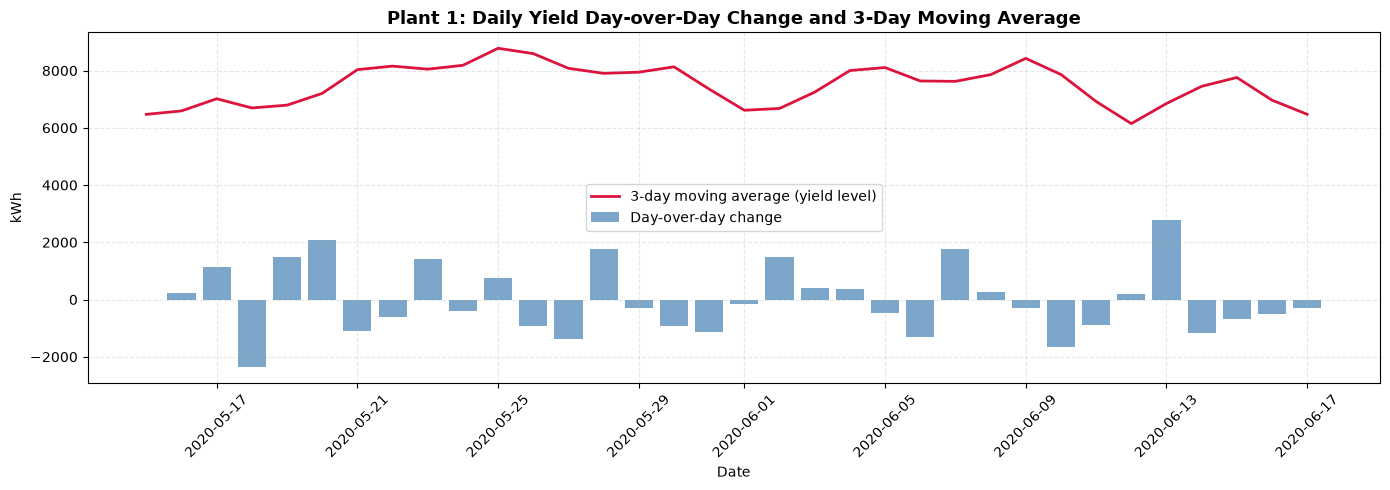

,day,daily_yield,day_over_day_change,moving_avg_3d
0,2020-05-15,6471.0,NaN,6471.000000
1,2020-05-16,6714.0,243.0,6592.500000
2,2020-05-17,7867.0,1153.0,7017.333333
3,2020-05-18,5506.0,-2361.0,6695.666667
4,2020-05-19,7007.0,1501.0,6793.333333
5,2020-05-20,9102.0,2095.0,7205.000000
6,2020-05-21,7993.0,-1109.0,8034.000000
7,2020-05-22,7378.0,-615.0,8157.666667


In [13]:
window_df = con.sql(f"""
    WITH daily AS (
        SELECT
            strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE AS day,
            max(DAILY_YIELD) AS daily_yield
        FROM read_csv_auto('{GEN_PATH}')
        GROUP BY day
    )
    SELECT
        day,
        daily_yield,
        daily_yield - LAG(daily_yield) OVER (ORDER BY day) AS day_over_day_change,
        AVG(daily_yield) OVER (ORDER BY day ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS moving_avg_3d
    FROM daily
    ORDER BY day
""").df()

plt.figure(figsize=(14, 5))
plt.bar(window_df['day'], window_df['day_over_day_change'], color='steelblue', alpha=0.7, label='Day-over-day change')
plt.plot(window_df['day'], window_df['moving_avg_3d'], color='crimson', lw=2, label='3-day moving average (yield level)')
plt.title('Plant 1: Daily Yield Day-over-Day Change and 3-Day Moving Average', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('kWh')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

window_df.head(8)


### 4.2 Grouped multi-aggregation

Per-inverter daily statistics (max/min/mean/count) in one query — the SQL equivalent of a `groupby().agg({...})` in pandas, and the same shape as a per-segment daily KPI table.


In [14]:
per_inverter_df = con.sql(f"""
    SELECT
        SOURCE_KEY,
        strptime(DATE_TIME, '%d-%m-%Y %H:%M')::DATE AS day,
        MAX(DC_POWER) AS dc_max,
        MIN(DC_POWER) AS dc_min,
        AVG(DC_POWER) AS dc_mean,
        COUNT(*) AS row_count
    FROM read_csv_auto('{GEN_PATH}')
    GROUP BY SOURCE_KEY, day
    ORDER BY day, SOURCE_KEY
""").df()

print(f"{len(per_inverter_df):,} rows (22 inverters x 34 days)")
per_inverter_df.head()


748 rows (22 inverters x 34 days)


,SOURCE_KEY,day,dc_max,dc_min,dc_mean,row_count
0,1BY6WEcLGh8j5v7,2020-05-15,10642.75000,0.0,2530.545123,93
1,1IF53ai7Xc0U56Y,2020-05-15,12194.71429,0.0,3082.275085,84
2,3PZuoBAID5Wc2HD,2020-05-15,12158.28571,0.0,3032.929209,84
3,7JYdWkrLSPkdwr4,2020-05-15,11674.75000,0.0,2983.432611,84
4,McdE0feGgRqW7Ca,2020-05-15,12040.57143,0.0,2839.042819,93


### 4.3 Time bucketing

`CASE WHEN` buckets each reading into peak (11:00-15:00) vs off-peak hours, then aggregates per bucket — the same pattern used to compare conversion rates or engagement by time-of-day segment.


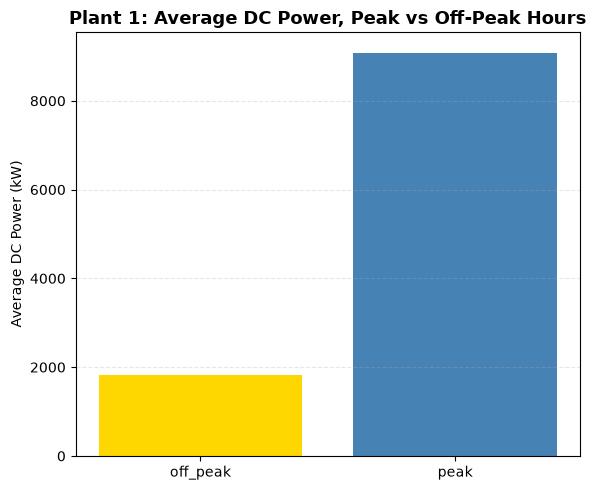

,period,n,avg_dc_power
0,off_peak,56300,1830.752881
1,peak,12478,9088.178614


In [15]:
bucket_df = con.sql(f"""
    WITH parsed AS (
        SELECT
            strptime(DATE_TIME, '%d-%m-%Y %H:%M') AS ts,
            DC_POWER
        FROM read_csv_auto('{GEN_PATH}')
    )
    SELECT
        CASE WHEN strftime(ts, '%H:%M') BETWEEN '11:00' AND '15:00' THEN 'peak' ELSE 'off_peak' END AS period,
        COUNT(*) AS n,
        AVG(DC_POWER) AS avg_dc_power
    FROM parsed
    GROUP BY period
""").df()

plt.figure(figsize=(6, 5))
plt.bar(bucket_df['period'], bucket_df['avg_dc_power'], color=['gold', 'steelblue'])
plt.title('Plant 1: Average DC Power, Peak vs Off-Peak Hours', fontsize=13, fontweight='bold')
plt.ylabel('Average DC Power (kW)')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

bucket_df
